## Plot PCA

In [1]:
%load_ext autoreload
%autoreload 2

In [28]:
from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer, quick_eval,
    seed_everything
)
from attribscope.svd2.utils import (
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
import torch
from pathlib import Path
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [3]:
REPS_ROOT:    Path = Path("/data/hoang/attrib/outputs")
DATA_ROOT:    Path = Path("data/ww")
OUTPUTS_ROOT: Path = None

MODEL:        str   = ["llama-3.1-8b", "qwen3-8b"][0] 
SUBSET:       str   = ["algorithm-generated", "hand-crafted"][1] 
REP_TYPE:     str   = ["grads", "hidden"][1]  
POOLING:      str   = ["grad", "mean", "last"][1]   # grads -> grad, hidden -> last | mean
WEIGHT_NAMES: str | list[str] = "all"
LOSS:         str   = "ntp"   
TEMPERATURE:  float | None = None

RATIO:        float = 0.5
SEED:         int   = 10
DEVICE: torch.device = torch.device("cuda:7")

In [4]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT, 
    model=MODEL, 
    subset=SUBSET,
    rep_type=REP_TYPE, 
    loss=LOSS, 
    temperature=TEMPERATURE,
    dir_type="representations"
)
data_dir = DATA_ROOT / SUBSET

print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")


Representation dir: /data/hoang/attrib/outputs/hidden/llama-3.1-8b/reps/hand-crafted
Data dir:           data/ww/hand-crafted


In [5]:
reps = load_representations(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names=WEIGHT_NAMES,
    device=DEVICE,
    files=None,
)

Loading representations: 100%|██████████| 58/58 [00:05<00:00, 11.10it/s]


In [6]:
import re
def sort_key(s):
    if s == 'embed': return (-1, 0, '')
    match = re.search(r'(\d+)', s)
    num = int(match.group(1))
    return (0, num, s)

layer_idxs = list(reps.stores.keys())
layer_idxs = sorted(layer_idxs, key=sort_key)
LAYER_IDX  = layer_idxs[31]
print(f"Layers: {layer_idxs}\n")
print(f"Selected layer: {LAYER_IDX}")

Layers: ['embed', 'act/0', 'act/1', 'act/2', 'act/3', 'act/4', 'act/5', 'act/6', 'act/7', 'act/8', 'act/9', 'act/10', 'act/11', 'act/12', 'act/13', 'act/14', 'act/15', 'act/16', 'act/17', 'act/18', 'act/19', 'act/20', 'act/21', 'act/22', 'act/23', 'act/24', 'act/25', 'act/26', 'act/27', 'act/28', 'act/29', 'act/30', 'act/31', 'act/31_normed']

Selected layer: act/30


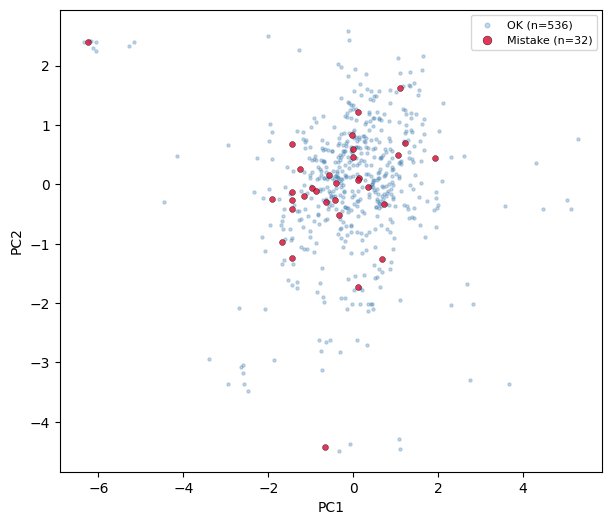

In [11]:
from attribscope.svd2.core import _run_svd
import numpy as np
import matplotlib.pyplot as plt

def standardize_role(role: str) -> str:
    if "Orchestrator (->" in role: 
        return "Orchestrator (-> Agent)"
    else: return role

roles = [standardize_role(x.role) for x in reps.keeper.index]
mistakes = [x.is_mistake for x in reps.keeper.index]

ROLE = ["WebSurfer", "Orchestrator (-> Agent)", "Orchestrator (thought)"][0]
idxs_by_role = [i for i, x in enumerate(roles) if x == ROLE]
LAYER_IDX = 28
AXES = [6, 8]

R = reps.stores[f'act/{LAYER_IDX}'].R
R_by_role = R[idxs_by_role, :].float()
mean_by_role = R_by_role.mean(dim=0)
mistake_by_role = np.array(mistakes)[idxs_by_role]

# V_by_role = _run_svd(R_by_role - mean_by_role, k=20)
# Z_by_role = (R_by_role - mean_by_role) @ V_by_role[:, AXES]

V_by_role = _run_svd(R_by_role, k=20)
Z_by_role = (R_by_role) @ V_by_role[:, AXES]


Z_cpu = Z_by_role.cpu().numpy()
is_mistake = mistake_by_role.astype(bool)

fig, ax = plt.subplots(figsize=(7, 6))

# correct samples in the background
ax.scatter(Z_cpu[~is_mistake, 0], Z_cpu[~is_mistake, 1],
           s=5, alpha=0.3, c='steelblue',
           label=f'OK (n={(~is_mistake).sum()})')

# mistakes on top, larger and brighter
ax.scatter(Z_cpu[is_mistake, 0], Z_cpu[is_mistake, 1],
           s=18, alpha=0.85, c='crimson',
           edgecolor='black', linewidth=0.3,
           label=f'Mistake (n={is_mistake.sum()})')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')            
ax.legend(fontsize=8, markerscale=1.5)
plt.show()

In [ ]:
R_by_role.shape
mistake_by_role

(568,)

Variance explained: 73.8%


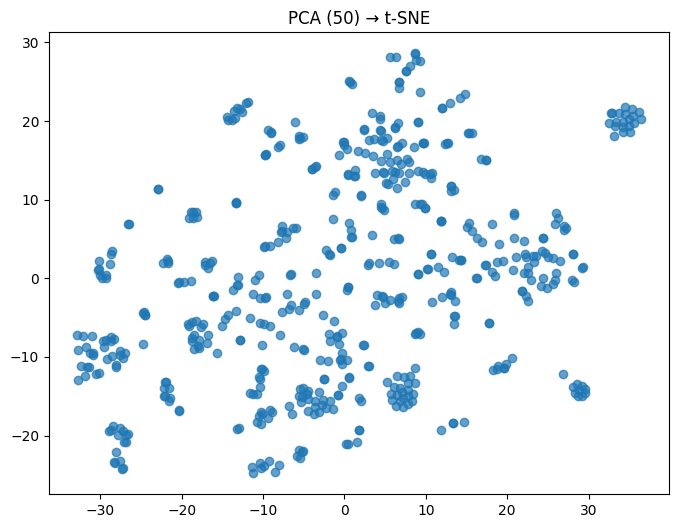

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Scale (important for high-d data)
X_scaled = StandardScaler().fit_transform(R_by_role.cpu().numpy())  # (500, 4000)

# 2. PCA to reduce to 50 dims first
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)           # (500, 50)

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

# 3. t-SNE on the PCA output
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X_pca)        # (500, 2)

# 4. Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.7)
plt.title("PCA (50) → t-SNE")
plt.show()

## Training full pipeline

In [1]:
%load_ext autoreload
%autoreload 2

In [74]:
from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer, quick_eval,
    seed_everything
)
from attribscope.svd2.utils import (
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
import torch
from pathlib import Path
import re
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

def downsample(X: torch.Tensor, y: torch.Tensor, weight: int = 1):
    """
    Undersample label 0 so that n(label 0) / n(label 1) = weight.
    All label 1 samples are kept.
    """
    idx_pos = (y == 1).nonzero(as_tuple=True)[0]
    idx_neg = (y == 0).nonzero(as_tuple=True)[0]

    n_neg_keep = min(len(idx_pos) * weight, len(idx_neg))
    idx_neg_sampled = idx_neg[torch.randperm(len(idx_neg))[:n_neg_keep]]

    idx_all = torch.cat([idx_pos, idx_neg_sampled])
    idx_all = idx_all[torch.randperm(len(idx_all))]  # shuffle

    return X[idx_all], y[idx_all]


def upsample(X: torch.Tensor, y: torch.Tensor, weight: int = 1):
    """
    Upsample label 1 (with replacement) so that n(label 0) / n(label 1) = weight.
    All label 0 samples are kept. If the current ratio is already <= weight,
    positives are left untouched (no downsampling of label 1).
    """
    idx_pos = (y == 1).nonzero(as_tuple=True)[0]
    idx_neg = (y == 0).nonzero(as_tuple=True)[0]

    n_pos_target = max(len(idx_neg) // weight, len(idx_pos))
    idx_pos_sampled = idx_pos[torch.randint(0, len(idx_pos), (n_pos_target,))]

    idx_all = torch.cat([idx_pos_sampled, idx_neg])
    idx_all = idx_all[torch.randperm(len(idx_all))]  # shuffle

    return X[idx_all], y[idx_all]

def sort_key(s):
    if s == 'embed': return (-1, 0, '')
    match = re.search(r'(\d+)', s)
    num = int(match.group(1))
    return (0, num, s)


In [4]:
REPS_ROOT:    Path = Path("/data/hoang/attrib/outputs")
DATA_ROOT:    Path = Path("data/ww")
OUTPUTS_ROOT: Path = None

MODEL:        str   = ["llama-3.1-8b", "qwen3-8b"][0] 
SUBSET:       str   = ["algorithm-generated", "hand-crafted"][0] 
REP_TYPE:     str   = ["grads", "hidden"][1]  
POOLING:      str   = ["grad", "mean", "last"][1]   # grads -> grad, hidden -> last | mean
WEIGHT_NAMES: str | list[str] = "all"
LOSS:         str   = "ntp"   
TEMPERATURE:  float | None = None

# RATIO:        float = 0.5
SEED:         int   = 10
DEVICE: torch.device = torch.device("cuda:5")


In [5]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT, 
    model=MODEL, 
    subset=SUBSET,
    rep_type=REP_TYPE, 
    loss=LOSS, 
    temperature=TEMPERATURE,
    dir_type="representations"
)
data_dir = DATA_ROOT / SUBSET

print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")

files = sorted(rep_dir.glob("*.safetensors"), key=lambda x: int(x.stem))
assert files, (f"No .safetensors files in {rep_dir}")

train_files, test_files = split_data(files, 0.5, SEED)
train_files, val_files  = split_data(train_files, 0.8, SEED)

print(f"Total train trajectories: {len(train_files)}")
print(f"Total val trajectories:   {len(val_files)}")
print(f"Total test trajectories:  {len(test_files)}")


Representation dir: /data/hoang/attrib/outputs/hidden/llama-3.1-8b/reps/algorithm-generated
Data dir:           data/ww/algorithm-generated
Total train trajectories: 50
Total val trajectories:   13
Total test trajectories:  63


In [6]:
rep_kwargs = dict(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names=WEIGHT_NAMES,
    device=DEVICE,
)

train_reps = load_representations(**rep_kwargs, files=train_files)
val_reps   = load_representations(**rep_kwargs, files=val_files)
test_reps  = load_representations(**rep_kwargs, files=test_files)

Loading representations:   0%|          | 0/50 [00:00<?, ?it/s]

Loading representations: 100%|██████████| 63/63 [00:01<00:00, 54.30it/s]


In [119]:
layer_idxs = list(train_reps.stores.keys())
layer_idxs = sorted(layer_idxs, key=sort_key)
LAYER_IDX  = layer_idxs[24]
print(f"Layers: {layer_idxs}\n")
print(f"Selected layer: {LAYER_IDX}")

Layers: ['embed', 'act/0', 'act/1', 'act/2', 'act/3', 'act/4', 'act/5', 'act/6', 'act/7', 'act/8', 'act/9', 'act/10', 'act/11', 'act/12', 'act/13', 'act/14', 'act/15', 'act/16', 'act/17', 'act/18', 'act/19', 'act/20', 'act/21', 'act/22', 'act/23', 'act/24', 'act/25', 'act/26', 'act/27', 'act/28', 'act/29', 'act/30', 'act/31', 'act/31_normed']

Selected layer: act/23


In [120]:
from attribscope.svd2.computation import (
    fit_one, score_one, fit_all, score_all
)
from attribscope.svd2.utils import run_metrics

In [121]:
svd = fit_all(train_reps.stores, n_components=10)

SVD fit: 100%|██████████| 34/34 [00:00<00:00, 78.32it/s]


In [ ]:
n_components_score = list(range(1, 11))
score_kwargs = dict(svd=svd, n_components_score=n_components_score, device=DEVICE)
train_scores = score_all(train_reps.stores, **score_kwargs)
val_scores   = score_all(val_reps.stores, **score_kwargs)

In [123]:
val_metrics = run_metrics(val_scores, keeper=val_reps.keeper, ks=[1])
config = val_metrics.query(
    f"weight == '{LAYER_IDX}' and direction == 'asc'"
).sort_values(["step_acc"], ascending=False).iloc[0].to_dict()
QUERY = (
    f"weight == '{LAYER_IDX}' "
    f"and pooling == '{config["pooling"]}' "
    f"and method  == '{config["method"]}' "
    f"and c == {config["c"]} "
    f"and centered == {config["centered"]}"
)
pseudo_scores = pd.DataFrame(train_scores).query(QUERY).iloc[0].scores

THRESHOLD = [x / 20 for x in range(1, 20)][1] # 0.1
print(f"Threshold: {THRESHOLD}")
wild_threshold = np.sort(pseudo_scores)[int(len(pseudo_scores) * THRESHOLD)]

Threshold: 0.1


In [124]:
X_train = train_reps.stores[LAYER_IDX].R
y_train = torch.Tensor(
    [idx.is_mistake for idx in  train_reps.keeper.index],
).to(device=X_train.device)
X_train = X_train.float().to(DEVICE)
y_pseudo = torch.Tensor(pseudo_scores < wild_threshold).to(device=X_train.device)

X_val = val_reps.stores[LAYER_IDX].R
y_val = torch.Tensor(
    [idx.is_mistake for idx in  val_reps.keeper.index],
).to(device=X_val.device)
X_val = X_val.float().to(DEVICE)


X_test = test_reps.stores[LAYER_IDX].R
y_test = torch.Tensor(
    [idx.is_mistake for idx in  test_reps.keeper.index],
).to(device=X_test.device)

# X_val, y_val = downsample(X_val, y_val, weight=1)
train_loader = DataLoader(TensorDataset(X_train, y_pseudo), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=512, shuffle=False)

In [135]:
seed_everything()
model = MLPClassifier(
    input_dim=X_train.shape[1], 
    hidden_dim=1024
)
clf, metrics = train(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=300,
    learning_rate=0.05,
    weight_decay=3e-4,
    momentum=0.9,
    pos_weight=None,
    logging_steps=100,
    val_metric="f1",
    device=next(iter(train_loader))[0].device,    
)

Epoch 100/300 - loss: 0.1058 | accuracy: 0.8367 | precision: 0.1111 | recall: 0.0909 | F1: 0.1000 | auroc: 0.5125 | val f1: 0.1176 (best: 0.1429)
Epoch 200/300 - loss: 0.0412 | accuracy: 0.8209 | precision: 0.0930 | recall: 0.0909 | F1: 0.0920 | auroc: 0.4864 | val f1: 0.2222 (best: 0.2222)
Epoch 300/300 - loss: 0.0352 | accuracy: 0.8299 | precision: 0.1395 | recall: 0.1364 | F1: 0.1379 | auroc: 0.5847 | val f1: 0.2222 (best: 0.2222)
Load from best state from epoch 300
Best f1: 0.2222222222222222


In [131]:
naive_clf = MLPClassifier(
    input_dim=X_train.shape[1], 
    hidden_dim=1024
)

In [137]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

mistake_indices, mistake_roles = get_mistake_meta(test_reps.keeper)
metrics = compute_metrics(
    scores=test_scores,
    keeper=test_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on test set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on test set:
Step@1: 0.3810 | Agent@1: 0.5714


In [107]:
quick_eval(clf, X_test, y_test)

{'accuracy': 0.8241758346557617,
 'precision': 0.3333333333333333,
 'recall': 0.5238095238095238,
 'f1': 0.40740740740740733,
 'auroc': 0.7708764665286405}

In [ ]:
X_train = train_reps.stores[LAYER_IDX].R
y_train = torch.Tensor(
    [idx.is_mistake for idx in  train_reps.keeper.index],
).to(device=X_train.device)
X_train = X_train.float().to(DEVICE)

# X_train, y_train = downsample(X_train, y_train, weight=1)
# y_train = y_train.float().to(DEVICE)


X_val = val_reps.stores[LAYER_IDX].R
y_val = torch.Tensor(
    [idx.is_mistake for idx in  val_reps.keeper.index],
).to(device=X_val.device)
X_val = X_val.float().to(DEVICE)
# y_val = y_train.float().to(DEVICE)

X_test = test_reps.stores[LAYER_IDX].R
y_test = torch.Tensor(
    [idx.is_mistake for idx in  test_reps.keeper.index],
).to(device=X_test.device)

# X_val, y_val = downsample(X_val, y_val, weight=1)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=512, shuffle=False)

In [92]:
import copy
import torch.nn as nn
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader = None,
    epochs: int = 50,
    learning_rate: float = 0.05,
    weight_decay: float = 3e-4,
    momentum: float = 0.9,
    pos_weight: torch.Tensor = None,
    logging_steps: int = 10,
    val_metric: str = None,
    device: str = "cuda",
) -> tuple[MLPClassifier, dict]:

    if pos_weight is not None:
        pos_weight = pos_weight.to(device)

    # clf = MLPClassifier(input_dim, hidden_dim).to(device)
    clf = model.to(device)
    optimizer = torch.optim.SGD(
        clf.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_score: float = -1.0
    best_state: dict | None = None
    best_epoch: int = -1

    for epoch in range(1, epochs + 1):
        clf.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.float().to(device), yb.float().to(device)
            logits = clf(xb).view(-1)
            loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        if val_loader is not None:
            X_val = torch.cat([xb for xb, _ in val_loader]).to(device)
            y_val = torch.cat([yb for _, yb in val_loader]).to(device)
            val_metrics = quick_eval(clf, X_val, y_val, device=device)
            val_score = val_metrics[val_metric]
            if val_score >= best_score:
                best_score = val_score
                best_state = copy.deepcopy(clf.state_dict())
                best_epoch = epoch

        if epoch % logging_steps == 0:
            avg_loss = epoch_loss / len(train_loader)
            X_tr = torch.cat([xb for xb, _ in train_loader]).to(device)
            y_tr = torch.cat([yb for _, yb in train_loader]).to(device)
            train_metrics = quick_eval(clf, X_tr, y_tr, device=device)
            log = (
                f"Epoch {epoch}/{epochs} - loss: {avg_loss:.4f}"
                f" | accuracy: {train_metrics['accuracy']:.4f}"
                f" | precision: {train_metrics['precision']:.4f}"
                f" | recall: {train_metrics['recall']:.4f}"
                f" | F1: {train_metrics['f1']:.4f}"
                f" | auroc: {train_metrics['auroc']:.4f}"
            )
            if val_loader is not None:
                log += f" | val {val_metric}: {val_score:.4f} (best: {best_score:.4f})"
            print(log)

    # Load best checkpoint if validation was used, else keep final weights
    if best_state is not None:
        print(f"Load from best state from epoch {best_epoch}")
        clf.load_state_dict(best_state)
        X_val = torch.cat([xb for xb, _ in val_loader]).to(device)
        y_val = torch.cat([yb for _, yb in val_loader]).to(device)
        val_metrics = quick_eval(clf, X_val, y_val, device=device)
        val_score = val_metrics[val_metric]
        print(f"Best {val_metric}: {val_score}")

    X_tr = torch.cat([xb for xb, _ in train_loader]).to(device)
    y_tr = torch.cat([yb for _, yb in train_loader]).to(device)
    final_metrics = quick_eval(clf, X_tr, y_tr, device=device)
    return clf, final_metrics

In [253]:
seed_everything()
model = MLPClassifier(
    input_dim=X_train.shape[1], 
    hidden_dim=1024
)
clf, metrics = train(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=500,
    learning_rate=0.05,
    weight_decay=3e-4,
    momentum=0.9,
    pos_weight=None,
    logging_steps=100,
    val_metric="f1",
    device=next(iter(train_loader))[0].device,    
)

Epoch 100/500 - loss: 0.1037 | accuracy: 0.8254 | precision: 0.1707 | recall: 0.1400 | F1: 0.1538 | auroc: 0.4862 | val f1: 0.3000 (best: 0.3158)
Epoch 200/500 - loss: 0.0202 | accuracy: 0.7959 | precision: 0.1000 | recall: 0.1000 | F1: 0.1000 | auroc: 0.4705 | val f1: 0.2400 (best: 0.3158)
Epoch 300/500 - loss: 0.0114 | accuracy: 0.7914 | precision: 0.0800 | recall: 0.0800 | F1: 0.0800 | auroc: 0.5047 | val f1: 0.2400 (best: 0.3158)
Epoch 400/500 - loss: 0.0095 | accuracy: 0.8050 | precision: 0.1400 | recall: 0.1400 | F1: 0.1400 | auroc: 0.5509 | val f1: 0.2400 (best: 0.3158)
Epoch 500/500 - loss: 0.0092 | accuracy: 0.7823 | precision: 0.0400 | recall: 0.0400 | F1: 0.0400 | auroc: 0.4536 | val f1: 0.2400 (best: 0.3158)
Load from best state from epoch 97
Best f1: 0.3157894736842105


In [254]:
quick_eval(clf, X_val, y_val)

{'accuracy': 0.8839285969734192,
 'precision': 0.5,
 'recall': 0.23076923076923078,
 'f1': 0.3157894736842105,
 'auroc': 0.8243978243978244}

In [239]:
# naive_clf = MLPClassifier(
#     input_dim=4096, hidden_dim=1024
# ).to(DEVICE)

In [255]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

mistake_indices, mistake_roles = get_mistake_meta(test_reps.keeper)
metrics = compute_metrics(
    scores=test_scores,
    keeper=test_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on test set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on test set:
Step@1: 0.4603 | Agent@1: 0.5714


In [216]:
A = y_test.int()

In [227]:
# B = (torch.sigmoid(test_scores) > 0.5).int()
B = (test_scores > 0.5).int()

In [228]:
(A == B).float().mean()

tensor(0.8755, device='cuda:7')

In [222]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

In [229]:
test_scores * 10000

tensor([3.7396e+03, 7.8582e-01, 5.5847e+02, 5.1230e-02, 7.2875e+02, 1.0531e+00,
        2.0605e+03, 1.6655e-01, 1.9163e+01, 2.5814e-01, 1.4320e+03, 4.8170e+03,
        1.4202e+01, 3.3195e+03, 1.5688e+03, 9.7702e-01, 1.3776e+02, 4.1515e+02,
        3.0988e+03, 3.6574e+02, 1.8510e+03, 5.7615e+02, 3.0818e+02, 4.4816e+02,
        2.0275e+03, 2.1676e-02, 1.3965e+02, 1.5812e+03, 1.8158e+02, 9.6951e-03,
        1.8236e-02, 2.0769e+03, 2.1107e-01, 1.6619e+03, 8.2597e+01, 1.5562e+03,
        2.5542e+03, 2.7882e+00, 1.3913e+03, 1.0305e-01, 1.2779e+03, 3.6291e+02,
        8.4533e+02, 1.3805e-01, 4.0960e+01, 2.5948e+03, 9.3934e+02, 1.6991e-04,
        1.8083e+02, 2.0867e+02, 1.0792e-04, 2.7361e+02, 2.7886e+03, 2.0180e-02,
        3.8569e+01, 4.1289e+01, 8.1432e-03, 2.9779e+02, 4.7053e+03, 4.6596e+01,
        4.9500e+01, 1.2432e+01, 1.6976e-02, 1.0153e+03, 1.6455e+02, 4.9111e+03,
        1.8580e+03, 4.7563e+02, 1.7510e+03, 1.2035e+02, 9.4421e+02, 7.2689e+01,
        5.8687e+02, 2.9165e+03, 7.5923e-

In [215]:
quick_eval(clf, X_test, y_test)

{'accuracy': 0.8754578828811646,
 'precision': 0.38095238095238093,
 'recall': 0.12698412698412698,
 'f1': 0.19047619047619047,
 'auroc': 0.8479739721975746}

In [186]:
test_scores = infer(
    clf, X_test,
    return_logits=False,
    device=X_test.device
)

mistake_indices, mistake_roles = get_mistake_meta(test_reps.keeper)
metrics = compute_metrics(
    scores=test_scores,
    keeper=test_reps.keeper,
    mistake_indices=mistake_indices,
    mistake_roles=mistake_roles,
    ks=[1],
    direction="desc"
)
step_acc, agent_acc = list(metrics.values())
print("Metrics on test set:")
print(f"Step@1: {step_acc:.4f} | Agent@1: {agent_acc:.4f}")

Metrics on test set:
Step@1: 0.4444 | Agent@1: 0.6032
